# Fe-Cu-Ni: GP + CUR convergence workflow

In [84]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import mpltern
import pickle

import sys
from gpr_grad import RBFKernelFunction, GradientGP, CUR_deterministic

torch.set_default_dtype(torch.float64)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'mathtext.default': 'regular',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.2,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.major.size': 3.0,
    'ytick.major.size': 3.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})
import pandas as pd


In [85]:
# constants
KB_IN_EV = 8.617e-5
T = 300.0
KB_T = KB_IN_EV * T
KB_T

0.025851

In [86]:
CSV_PATH = 'S0_NaClIWater_matrix_DH_s_loss_split0.csv'
df = pd.read_csv(CSV_PATH)
df_selected = df.loc[df['kcut'] == 0.005]

In [87]:
#import s0_grad

#import importlib
#importlib.reload(s0_grad)

from szero import (
    prepare_gp_gradient_data,
    pure_component_anchor,
    atomic_fraction_to_xtilde,
)

In [88]:
column_map = {
    "x_O": "x_O",
    "x_Na": "x_Na",
    "x_Cl": "x_Cl",
    "x_I": "x_I",
    "S_OO": "S0_OO",
    "S_ONa": "S0_ONa",
    "S_OCl": "S0_OCl",
    "S_NaNa": "S0_NaNa",
    "S_NaCl": "S0_NaCl",
    "S_ClCl": "S0_ClCl",
    "S_NaI": "S0_NaI",
    "S_ClI": "S0_ClI",
    "S_OI": "S0_OI",
    "S_II": "S0_II",   
}

independent_components = ["Cl", "I"]
components = ["O", "Na", "Cl", "I"]


# selected multiple species: returns dict
gp_grad_data = prepare_gp_gradient_data(
    df_selected,
    independent_components=independent_components,
    column_map=column_map,
    components=components,
    species=["O", "Na", "Cl", "I"], # for which species to return the chemical potential gradients. Can be a list or str
    temperature=300.0,
    excess=True,  # return the gradients for excess potential
    charges={"Na": 1, "Cl": -1,"I": -1, "O":0},
    as_torch=True,
)

In [89]:
# -----------------------------
# prediction grid
# -----------------------------
xs = torch.linspace(0.0, 0.1, 21)
ys = torch.linspace(0.0, 0.1, 21)

xx, yy = torch.meshgrid(xs, ys, indexing="ij")
X_star = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
X_star = X_star[X_star.sum(dim=1) <= 0.12]

In [90]:
mu_gp = {}
for species_now in components:
    X_g, G_g, grad_indices = gp_grad_data[species_now]
    X_f, Y_f = torch.tensor([[0.001, 0.001]]), torch.tensor([0.0])

    # -----------------------------
    # fit GP
    # -----------------------------
    # Trainable RBF length scales
    kernel = RBFKernelFunction(
        theta=torch.tensor([0.05, 0.05]),
        trainable=False,
    )

    gp = GradientGP(
        kernel=kernel,
        sigma_f=0.0,
        sigma_g=0.1,
        trainable_sigma_f=False,
        trainable_sigma_g=False,
        jitter=1e-8,
    )

    gp.fit(X_f=X_f, 
           Y_f=Y_f, 
           X_g=X_g, 
           G_g=G_g, 
           grad_indices=grad_indices,)

    mu_gp[species_now] = gp

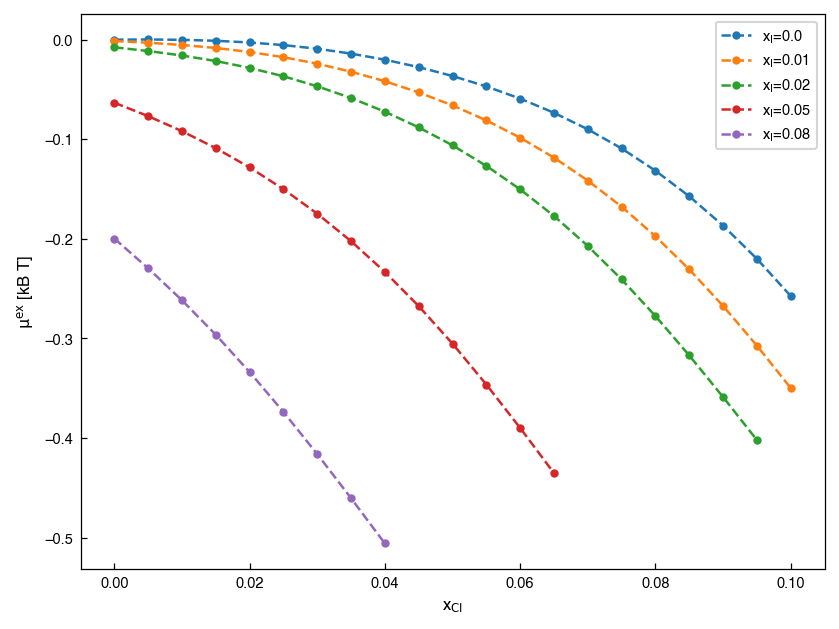

In [91]:
species_now = 'O'
gp = mu_gp[species_now]

for x_I in [0.0, 0.01, 0.02, 0.05, 0.08]:
    X_select = X_star[X_star[:,1] == x_I]
    mean, cov = gp.predict(X_select)

    plt.plot(X_select[:,0], mean/KB_T, 
             '.', ls='--', label='$x_\mathrm{I}$=' + str(x_I))


plt.ylabel('$\mu^\mathrm{ex}$ [kB T]')
plt.xlabel('$x_\mathrm{Cl}$')

plt.legend()

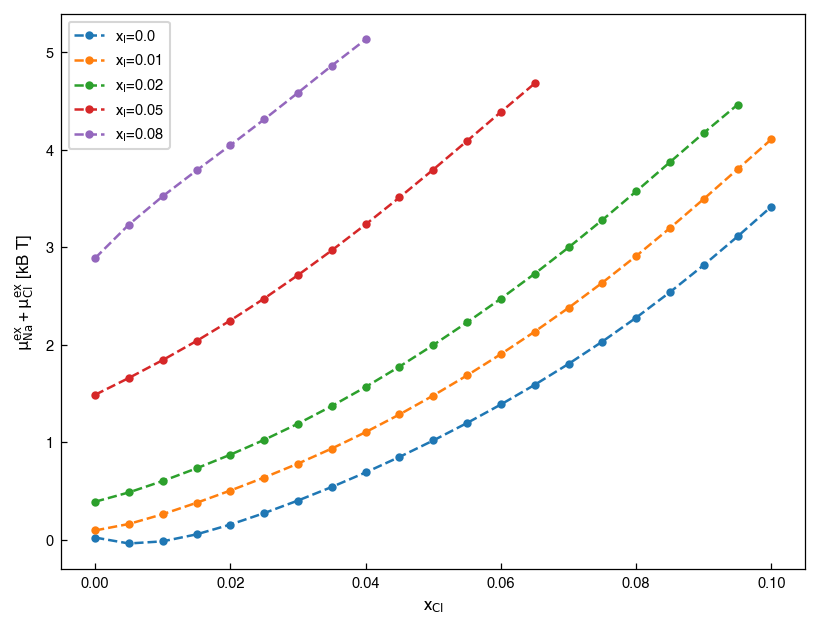

In [92]:
for x_I in [0.0, 0.01, 0.02, 0.05, 0.08]:
    X_select = X_star[X_star[:,1] == x_I]
    
    mu_Na, _ = mu_gp['Na'].predict(X_select)
    mu_Cl, _ = mu_gp['Cl'].predict(X_select)

    plt.plot(X_select[:,0], (mu_Na + mu_Cl)/KB_T, 
             '.', ls='--', label='$x_\mathrm{I}$=' + str(x_I))


plt.ylabel('$\mu^\mathrm{ex}_\mathrm{Na} + \mu^\mathrm{ex}_\mathrm{Cl}$ [kB T]')
plt.xlabel('$x_\mathrm{Cl}$')

plt.legend()